In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.model_selection import GridSearchCV



# Read CSV FIle and print first first few rows

In [50]:
df=pd.read_csv('BeansMulticlassClassification.csv')
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [51]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

# Check for null values

In [53]:
df.isnull().sum() 

           Area                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

# Histogram visualization

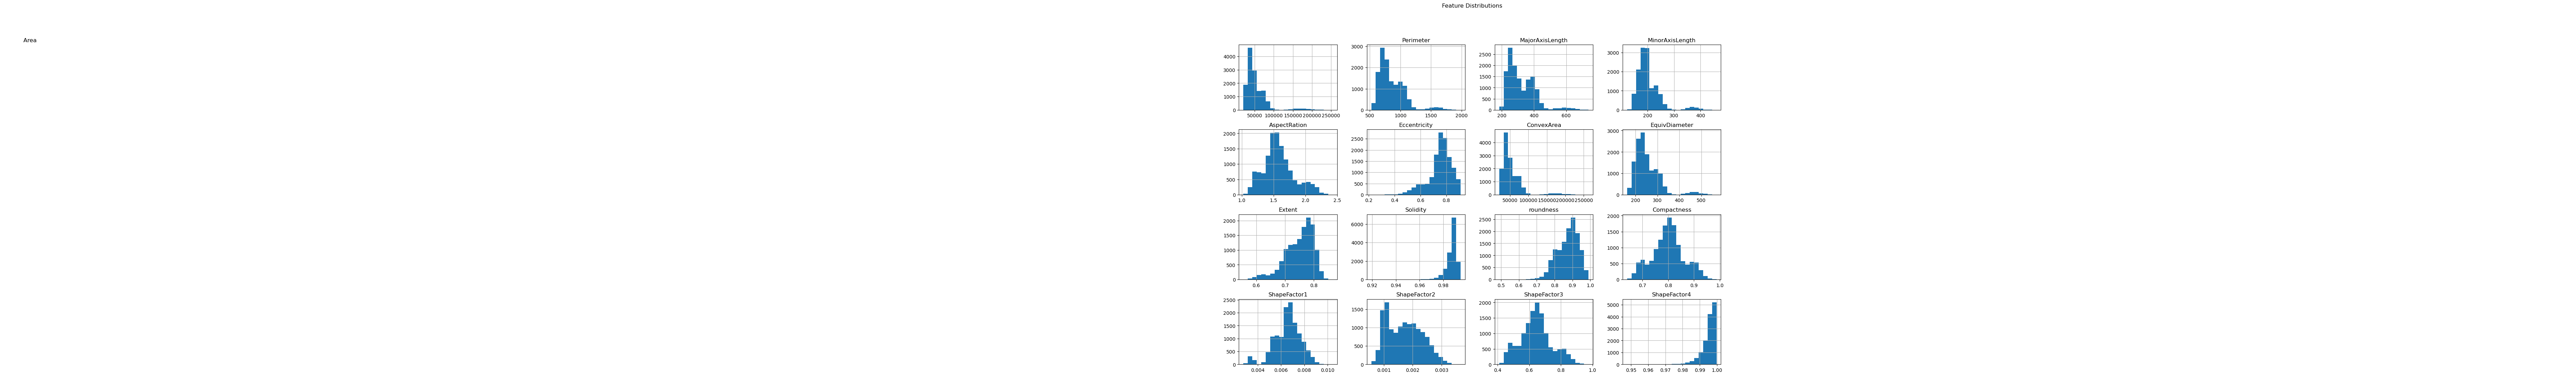

In [54]:
df.hist(figsize=(18,12), bins=20)
plt.suptitle("Feature Distributions")
plt.show()


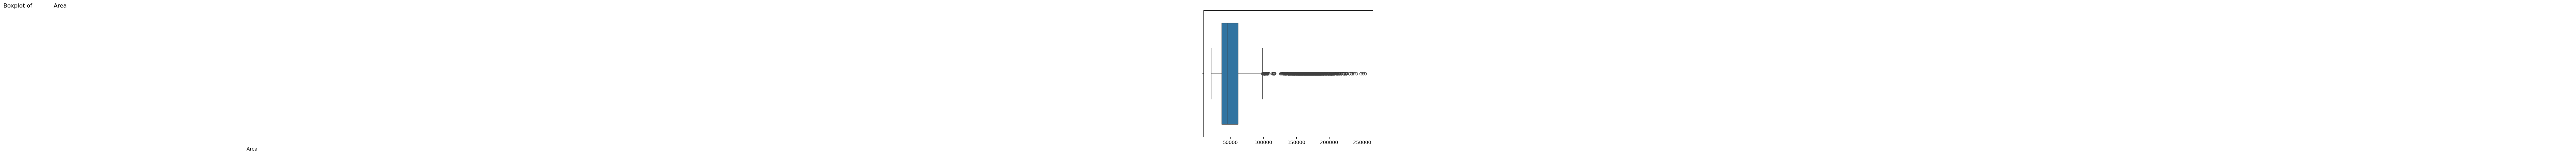

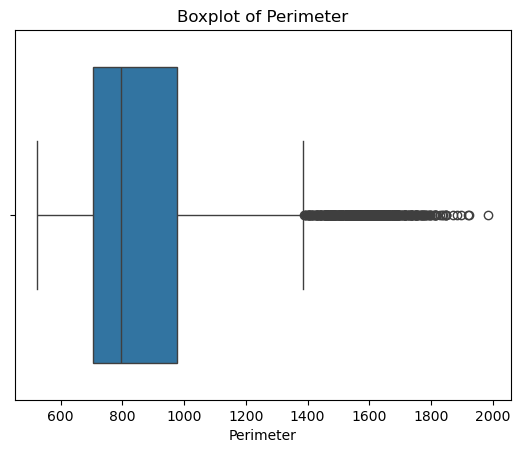

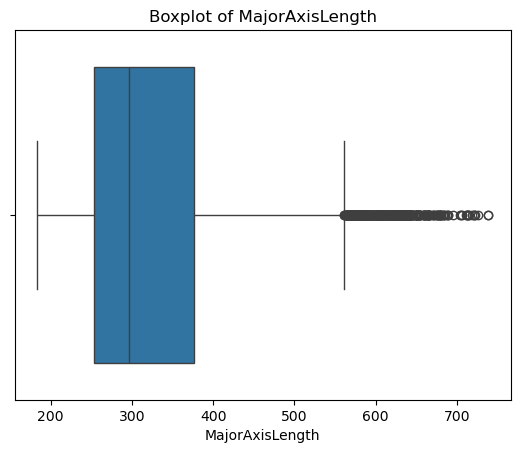

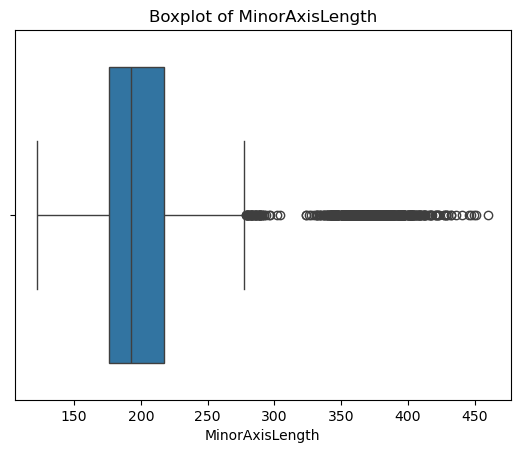

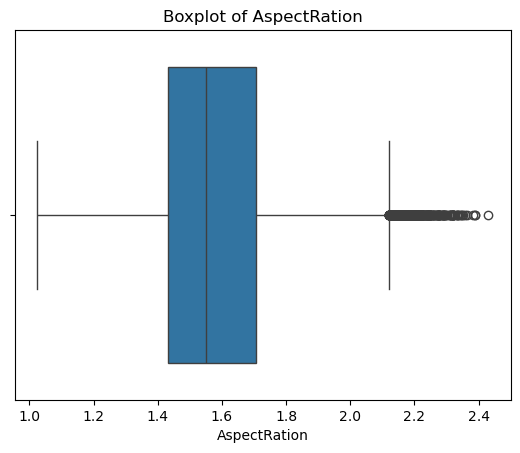

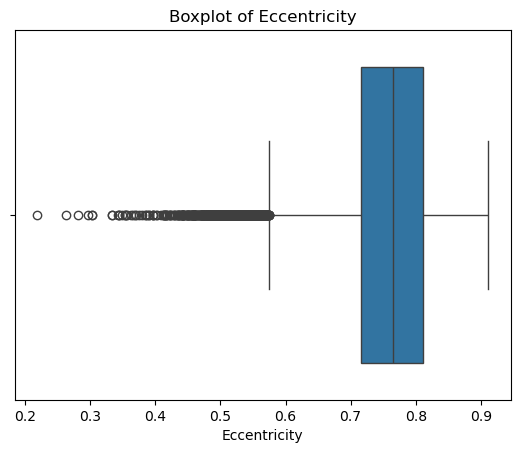

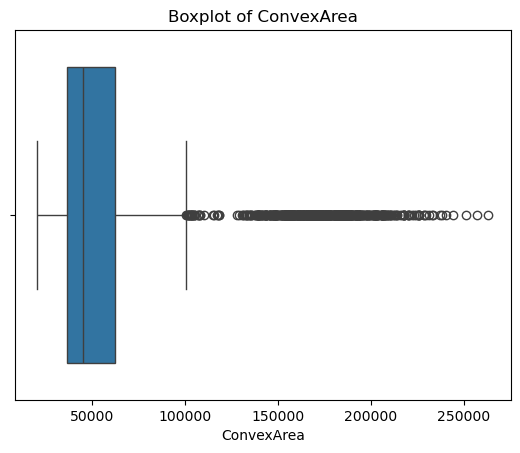

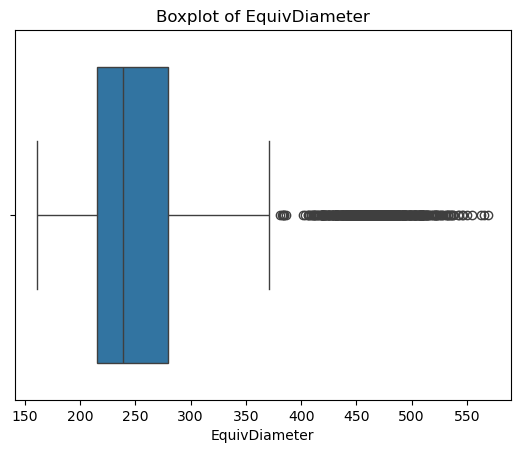

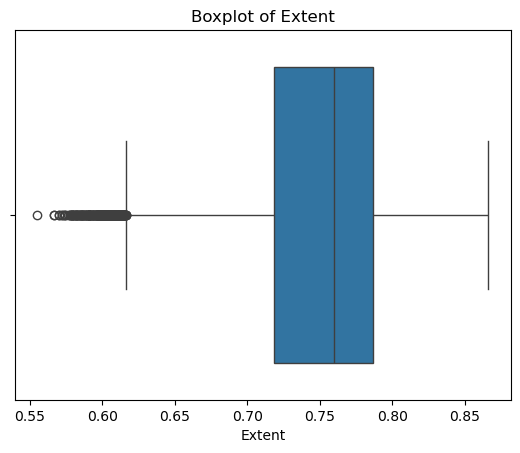

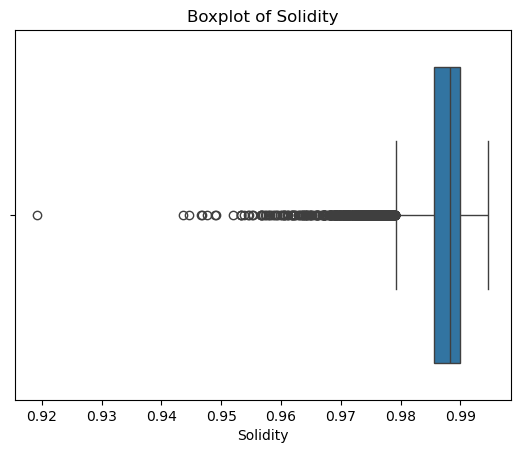

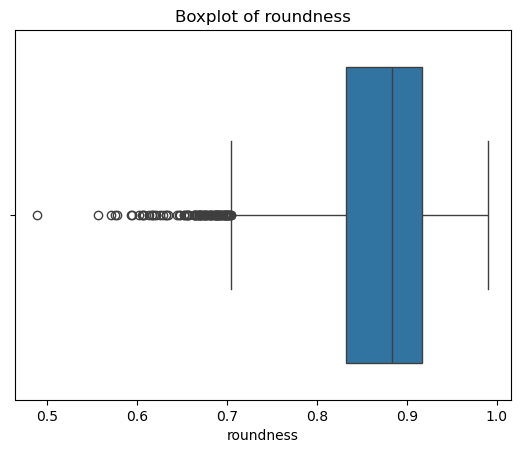

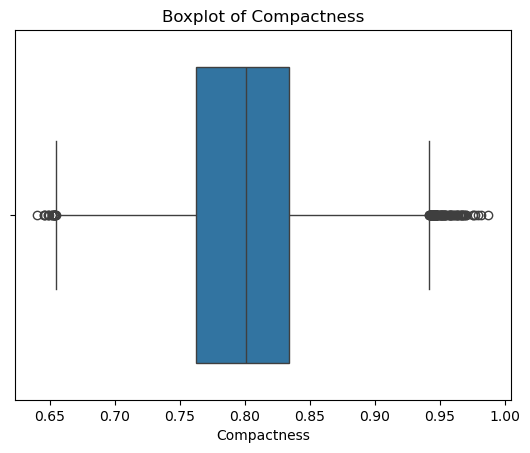

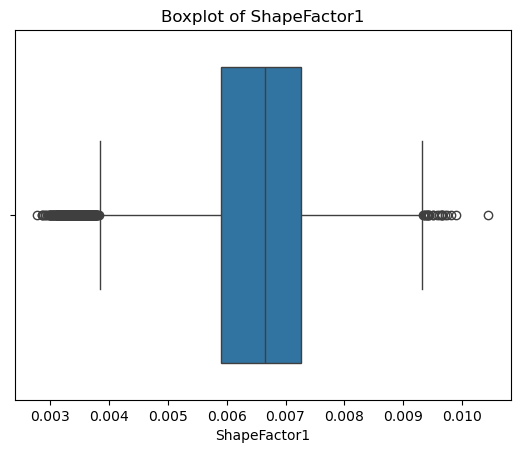

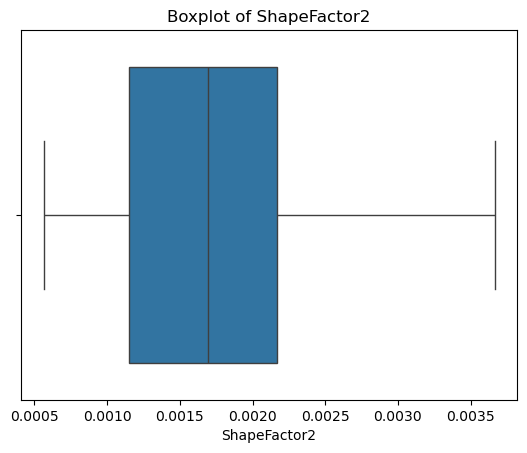

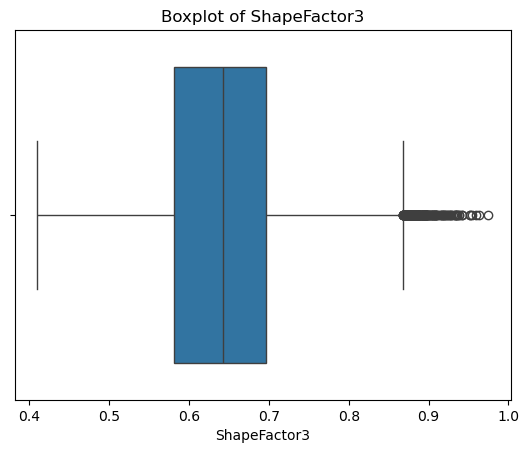

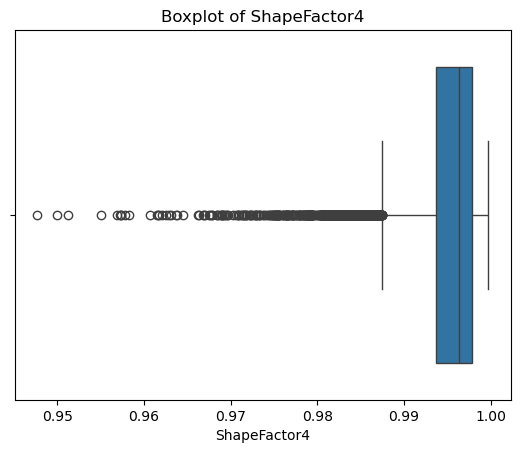

In [55]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# Boxplots reveal presence of outliers, especially in size-related features, so Using Capping to treat outliars

In [56]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

# Check for Outliars again After treatment

In [57]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

           Area                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

# Class Distribution check to detect class Imbalance

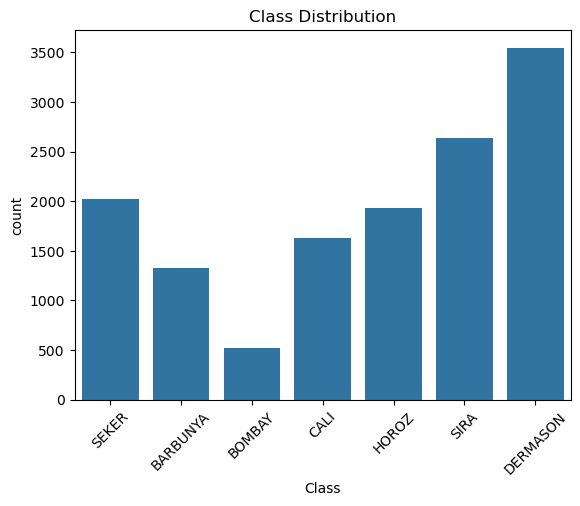

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


In [58]:

sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

print(df['Class'].value_counts())

# Dataset is imbalanced. Classes like DERMASON have significantly more samples compared to BOMBAY. So I will be using stratified sampling

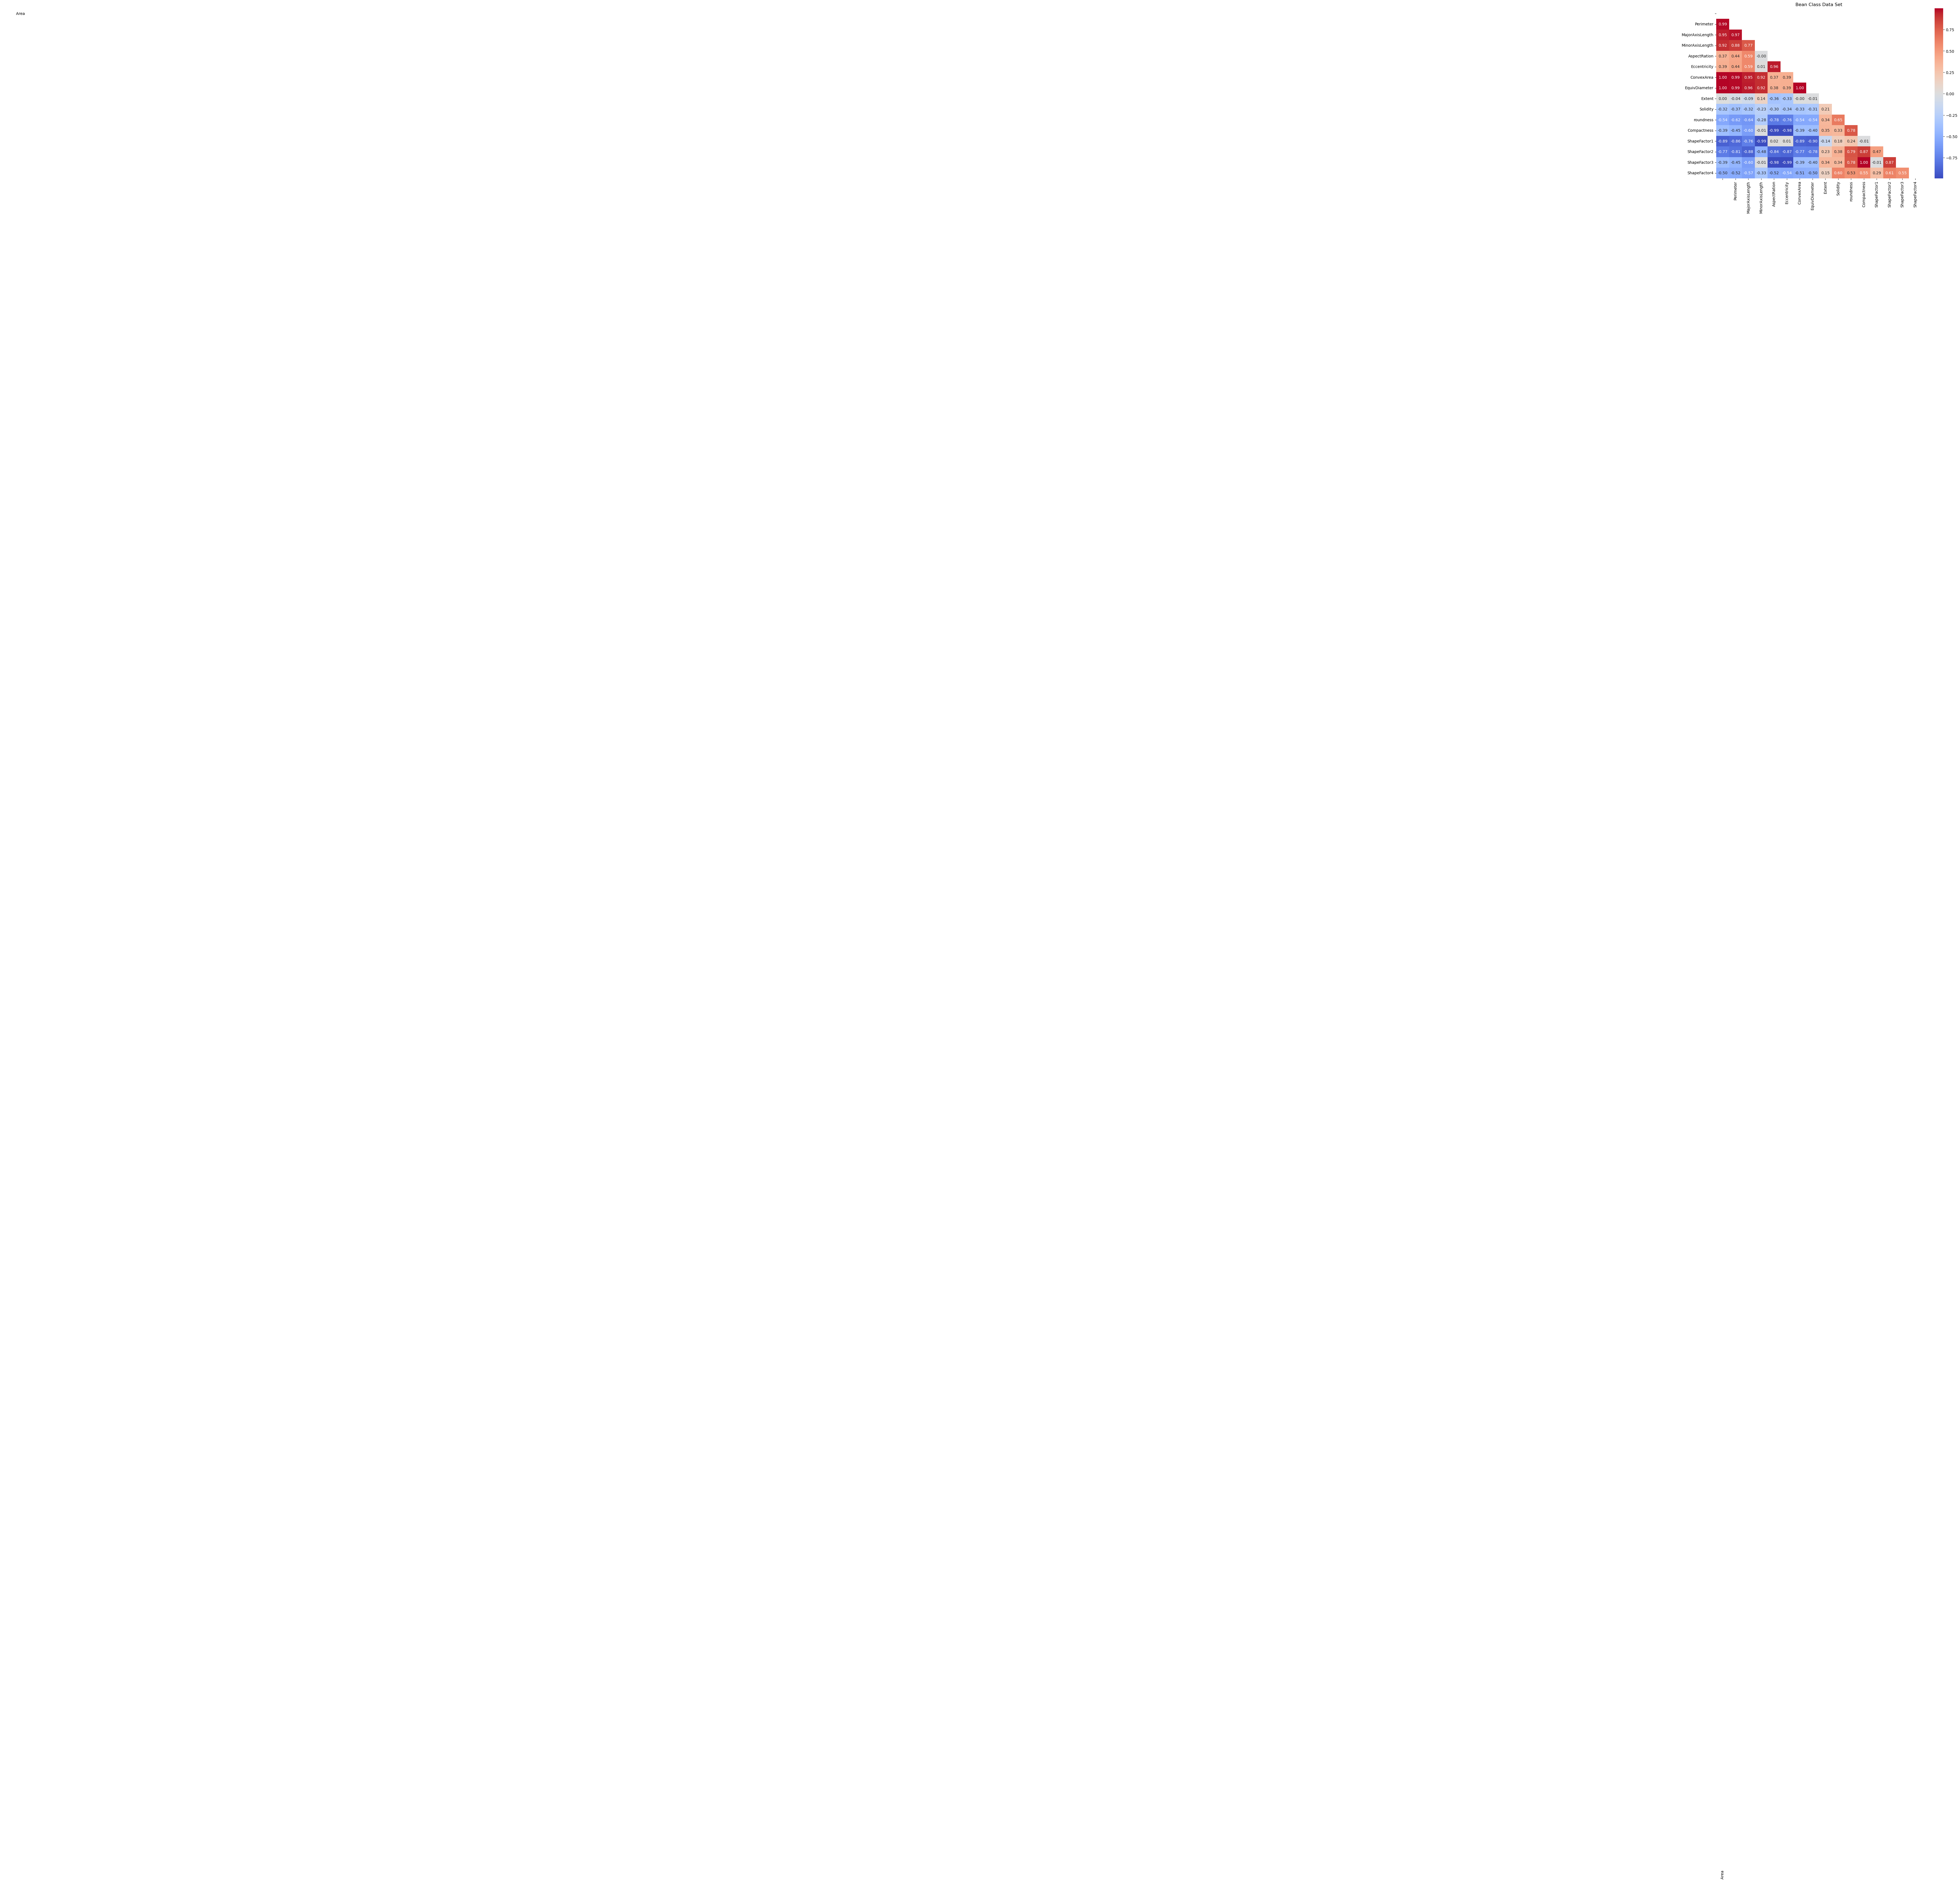

In [59]:
corr = df.corr(numeric_only=True)

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    mask=mask,          # hides upper triangle
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Bean Class Data Set")
plt.show()

# Separate X and Y

In [60]:
X = df.drop('Class', axis=1)
y = df['Class']

In [61]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.57412,28715.0,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.57412,29172.0,191.272751,0.783968,0.984986,0.887034,0.941972,0.006979,0.003564,0.867978,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.57412,29690.0,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.57412,30724.0,195.467062,0.782681,0.979156,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.57412,30417.0,195.896503,0.773098,0.990893,0.984877,0.941972,0.006697,0.003665,0.867978,0.999166,SEKER


# Check and treat Skewness

In [62]:
skewness = X.skew()
print("Skewness:\n", skewness)

Skewness:
            Area                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

# Skewness is not there, Now let us do feature scaling

In [63]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.15810104, -1.25600124, -1.37425439, ...,  2.4021726 ,
         1.94592675,  1.02115472],
       [-1.14007413, -1.10927944, -1.46952836, ...,  3.10089364,
         2.28987959,  0.93205583],
       [-1.10572196, -1.18287581, -1.31639263, ...,  2.23509111,
         1.86082593,  1.12503171],
       ...,
       [-0.4272401 , -0.46738544, -0.46099454, ...,  0.28920501,
         0.34272042,  0.42729206],
       [-0.42681468, -0.44379523, -0.43805519, ...,  0.22837456,
         0.25460645, -0.04158938],
       [-0.42617656, -0.39903839, -0.29165707, ..., -0.12777538,
        -0.27541433,  0.85596249]])

# Train-Test Split (Dataset is imbalanced. Classes like DERMASON have significantly more samples compared to BOMBAY. So I will be using stratified sampling)

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [65]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Before:", y_train.shape)
print("After:", y_resampled.shape)

Before: (10888,)
After: (19859,)


# Create a function to avoid duplicate code each time we want to train a model

In [66]:
# Create a function to avoid duplicate code each time we want to train a model
def train_and_evaluate_model(model, x_train, y_train, x_test, y_test):
    
    # Train
    model.fit(x_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    # ================= TRAIN METRICS =================
    train_acc = accuracy_score(y_train, y_train_pred)
    train_prec = precision_score(y_train, y_train_pred, average='weighted')
    train_rec = recall_score(y_train, y_train_pred, average='weighted')
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    train_cm = confusion_matrix(y_train, y_train_pred)

    # ================= TEST METRICS =================
    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred, average='weighted')
    test_rec = recall_score(y_test, y_test_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    test_cm = confusion_matrix(y_test, y_test_pred)

    # ================= PRINT =================
    print(f"\nModel: {model.__class__.__name__}")
    
    print("\nTraining Results:")
    print(f"Accuracy: {train_acc:.4f}")
    print(f"Precision: {train_prec:.4f}")
    print(f"Recall: {train_rec:.4f}")
    print(f"F1 Score: {train_f1:.4f}")
    print("Confusion Matrix:\n", train_cm)
    
    print("\nTesting Results:")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Precision: {test_prec:.4f}")
    print(f"Recall: {test_rec:.4f}")
    print(f"F1 Score: {test_f1:.4f}")
    print("Confusion Matrix:\n", test_cm)

    # ================= RETURN =================
    return {
        'Model': model.__class__.__name__,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Train Precision': train_prec, 
        'Test Precision': test_prec,
        'Train Recall': train_rec,
        'Test Recall': test_rec,
        'Train F1': train_f1,
        'Test F1': test_f1,
        'Train Confusion Matrix': train_cm,
        'Test Confusion Matrix': test_cm
    }

In [67]:
models = [
    LogisticRegression(max_iter=2000),
    DecisionTreeClassifier(random_state=42),
    RandomForestClassifier(random_state=42),
    KNeighborsClassifier(),
    SVC(),
    GaussianNB(),
    GradientBoostingClassifier()
]

for model in models:
    train_and_evaluate_model(model, X_resampled, y_resampled, X_test, y_test)


Model: LogisticRegression

Training Results:
Accuracy: 0.9413
Precision: 0.9416
Recall: 0.9413
F1 Score: 0.9414
Confusion Matrix:
 [[2677    0  101    0   11   12   36]
 [   0 2837    0    0    0    0    0]
 [  75    0 2703    0   41    2   16]
 [   1    0    0 2545    9   47  235]
 [   9    0   39   19 2724    0   46]
 [  18    0    1   32    0 2705   81]
 [   9    0    9  213   59   45 2502]]

Testing Results:
Accuracy: 0.9203
Precision: 0.9219
Recall: 0.9203
F1 Score: 0.9206
Confusion Matrix:
 [[243   0  14   0   0   3   5]
 [  0 104   0   0   0   0   0]
 [ 10   0 307   0   5   2   2]
 [  0   0   0 623   0  15  71]
 [  1   0   5   5 368   0   7]
 [  4   0   0   3   0 390   9]
 [  2   0   2  30  10  12 471]]

Model: DecisionTreeClassifier

Training Results:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
 [[2837    0    0    0    0    0    0]
 [   0 2837    0    0    0    0    0]
 [   0    0 2837    0    0    0    0]
 [   0    0    0 2837    0   

# For SVC, Random Forest and Gradient boost using Grid search CV

In [68]:
svm = SVC()

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    svm,
    svm_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

svm_grid.fit(X_resampled, y_resampled)

print("SVM Best Params:", svm_grid.best_params_)

# Evaluate using your function
train_and_evaluate_model(
    svm_grid.best_estimator_,
    X_resampled, y_resampled,
    X_test, y_test
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
SVM Best Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

Model: SVC

Training Results:
Accuracy: 0.9546
Precision: 0.9548
Recall: 0.9546
F1 Score: 0.9547
Confusion Matrix:
 [[2727    0   79    0    5    8   18]
 [   0 2837    0    0    0    0    0]
 [  47    0 2752    0   27    2    9]
 [   0    0    0 2638    2   40  157]
 [   9    0   32   17 2735    0   44]
 [   9    0    0   38    0 2739   51]
 [   8    0    5  228   34   32 2530]]

Testing Results:
Accuracy: 0.9243
Precision: 0.9243
Recall: 0.9243
F1 Score: 0.9243
Confusion Matrix:
 [[243   0  13   0   1   3   5]
 [  0 104   0   0   0   0   0]
 [ 11   0 305   0   5   3   2]
 [  0   0   0 646   0  14  49]
 [  2   0   4   6 369   0   5]
 [  4   0   0   4   0 391   7]
 [  4   0   2  46   9   7 459]]


{'Model': 'SVC',
 'Train Accuracy': 0.9546301425046578,
 'Test Accuracy': 0.9243481454278369,
 'Train Precision': 0.9548495154161004,
 'Test Precision': 0.9243267574930802,
 'Train Recall': 0.9546301425046578,
 'Test Recall': 0.9243481454278369,
 'Train F1': 0.9546926499942912,
 'Test F1': 0.9242992673134824,
 'Train Confusion Matrix': array([[2727,    0,   79,    0,    5,    8,   18],
        [   0, 2837,    0,    0,    0,    0,    0],
        [  47,    0, 2752,    0,   27,    2,    9],
        [   0,    0,    0, 2638,    2,   40,  157],
        [   9,    0,   32,   17, 2735,    0,   44],
        [   9,    0,    0,   38,    0, 2739,   51],
        [   8,    0,    5,  228,   34,   32, 2530]]),
 'Test Confusion Matrix': array([[243,   0,  13,   0,   1,   3,   5],
        [  0, 104,   0,   0,   0,   0,   0],
        [ 11,   0, 305,   0,   5,   3,   2],
        [  0,   0,   0, 646,   0,  14,  49],
        [  2,   0,   4,   6, 369,   0,   5],
        [  4,   0,   0,   4,   0, 391,   7],
  

In [69]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_resampled, y_resampled)

print("RF Best Params:", rf_grid.best_params_)

train_and_evaluate_model(
    rf_grid.best_estimator_,
    X_resampled, y_resampled,
    X_test, y_test
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
RF Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Model: RandomForestClassifier

Training Results:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
 [[2837    0    0    0    0    0    0]
 [   0 2837    0    0    0    0    0]
 [   0    0 2837    0    0    0    0]
 [   0    0    0 2837    0    0    0]
 [   0    0    0    0 2837    0    0]
 [   0    0    0    0    0 2837    0]
 [   0    0    0    0    0    0 2837]]

Testing Results:
Accuracy: 0.9214
Precision: 0.9212
Recall: 0.9214
F1 Score: 0.9212
Confusion Matrix:
 [[237   0  17   0   1   2   8]
 [  0 104   0   0   0   0   0]
 [ 13   0 303   0   5   2   3]
 [  0   0   0 650   2  12  45]
 [  2   0   4   4 370   0   6]
 [  1   0   0   5   0 393   7]
 [  4   0   0  51   9  11 452]]


{'Model': 'RandomForestClassifier',
 'Train Accuracy': 1.0,
 'Test Accuracy': 0.9214102093279471,
 'Train Precision': 1.0,
 'Test Precision': 0.9212198351994301,
 'Train Recall': 1.0,
 'Test Recall': 0.9214102093279471,
 'Train F1': 1.0,
 'Test F1': 0.9212466166931791,
 'Train Confusion Matrix': array([[2837,    0,    0,    0,    0,    0,    0],
        [   0, 2837,    0,    0,    0,    0,    0],
        [   0,    0, 2837,    0,    0,    0,    0],
        [   0,    0,    0, 2837,    0,    0,    0],
        [   0,    0,    0,    0, 2837,    0,    0],
        [   0,    0,    0,    0,    0, 2837,    0],
        [   0,    0,    0,    0,    0,    0, 2837]]),
 'Test Confusion Matrix': array([[237,   0,  17,   0,   1,   2,   8],
        [  0, 104,   0,   0,   0,   0,   0],
        [ 13,   0, 303,   0,   5,   2,   3],
        [  0,   0,   0, 650,   2,  12,  45],
        [  2,   0,   4,   4, 370,   0,   6],
        [  1,   0,   0,   5,   0, 393,   7],
        [  4,   0,   0,  51,   9,  11, 452]

In [70]:
#gb = GradientBoostingClassifier()

#gb_params = {
#    'n_estimators': [100, 200],
#    'learning_rate': [0.05, 0.1],
#'max_depth': [3, 5]
#}

#gb_grid = GridSearchCV(
#    gb,
#    gb_params,
#    cv=5, 
#    scoring='accuracy',
#    n_jobs=-1,
#    verbose=2
#)

#gb_grid.fit(X_resampled, y_resampled)

#print("GB Best Params:", gb_grid.best_params_)

#train_and_evaluate_model(
#    gb_grid.best_estimator_,
#    X_resampled, y_resampled,
#    X_test, y_test
#)

# Compare Tuned Models

In [71]:
tuned_results = []

tuned_results.append(
    train_and_evaluate_model(
        svm_grid.best_estimator_,
        X_resampled, y_resampled,
        X_test, y_test
    )
)

tuned_results.append(
    train_and_evaluate_model(
        rf_grid.best_estimator_,
        X_resampled, y_resampled,
        X_test, y_test
    )
)

tuned_results.append(
    train_and_evaluate_model(
        gb_grid.best_estimator_,
        X_resampled, y_resampled,
        X_test, y_test
    )
)

import pandas as pd


Model: SVC

Training Results:
Accuracy: 0.9546
Precision: 0.9548
Recall: 0.9546
F1 Score: 0.9547
Confusion Matrix:
 [[2727    0   79    0    5    8   18]
 [   0 2837    0    0    0    0    0]
 [  47    0 2752    0   27    2    9]
 [   0    0    0 2638    2   40  157]
 [   9    0   32   17 2735    0   44]
 [   9    0    0   38    0 2739   51]
 [   8    0    5  228   34   32 2530]]

Testing Results:
Accuracy: 0.9243
Precision: 0.9243
Recall: 0.9243
F1 Score: 0.9243
Confusion Matrix:
 [[243   0  13   0   1   3   5]
 [  0 104   0   0   0   0   0]
 [ 11   0 305   0   5   3   2]
 [  0   0   0 646   0  14  49]
 [  2   0   4   6 369   0   5]
 [  4   0   0   4   0 391   7]
 [  4   0   2  46   9   7 459]]

Model: RandomForestClassifier

Training Results:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
 [[2837    0    0    0    0    0    0]
 [   0 2837    0    0    0    0    0]
 [   0    0 2837    0    0    0    0]
 [   0    0    0 2837    0    0    0]
 [   0

# To compare performace of different algorithms, create result matrix, and we see Random Forest and XGB giving Good Accuracy

In [72]:
# Create a result matrix for comparing different models
results_df = pd.DataFrame([results_DecisionTree, results_RandomForest, results_XGB, results_LogisticRegression])
results_df

NameError: name 'results_DecisionTree' is not defined

# Going with XGB Model 

In [73]:
import joblib

Final_model = svm_grid.best_estimator_
Final_model.fit(X_resampled, y_resampled)

joblib.dump(Final_model, 'BeanClassifier.pkl')
scaler_filename = 'BeanClassifierScaler.pkl'
joblib.dump(scaler, scaler_filename)

['BeanClassifierScaler.pkl']